# Gene-expression reconstruction autoencoder

Train a small autoencoder (`scaleflow.model._recon`) that maps gene expression to a latent
space and back, so that later the flow model's predictions — which live in the 2058-d
cell-state space (`X_state`) — can be **decoded back to gene expression** and compared to
ground truth.

Two experiments:
- **Part A — learned latent.** Train the full `Autoencoder` (genes -> latent -> genes).
- **Part B — predefined latent.** Train a `Decoder` alone to map the existing `X_state`
  embedding -> gene expression.

Metrics on held-out test cells (all on mean profiles, `scaleflow`-style): per-cell-line
**pseudobulk R²** (baseline-dominated), **perturbation-delta R²** and **delta Pearson r**
(control-subtracted → measures the drug effect; Pearson is scale-independent). Loss + all
metrics are logged to **wandb** (project `pancellflow`, group `recon_test`) every `CHUNK`
iters so the runs can be compared along training. Runs in the `pancellflow` env.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import anndata as ad
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import wandb

import scaleflow
from scaleflow.model._recon import Autoencoder, Decoder

sc.settings.verbosity = 1
print("scaleflow:", scaleflow.__file__)
print("jax devices:", jax.devices())

scaleflow: /ictstr01/groups/ml01/workspace/xiaotong.fu/pancellflow/sub/src/scaleflow/__init__.py
jax devices: [CudaDevice(id=0)]


In [2]:
# ---- configuration ----
DATA_PATH = "/lustre/groups/ml01/workspace/karthik.viswanathan/pancellflow/filtered_data/sciplex3_prophet_filtered.h5ad"
SEED = 0
N_SUBSAMPLE = None       # None -> use ALL cells (full ~518k); set an int to subsample
N_TOP_GENES = 2000       # HVGs reconstructed
LATENT_DIM = 128         # learned-latent dimensionality (Part A)
DEC_HIDDEN = (2000, 2000)  # decoder hidden layers (both Part A decoder and Part B decoder)
N_ITERS = 150_000        # training iterations
CHUNK = 10_000           # log test metrics every CHUNK iterations
BATCH_SIZE = 256
LR = 1e-3
TEST_FRAC = 0.2
MIN_CELLS_DELTA = 20     # min treated test cells per (cell_line, drug) for the delta metrics
UMAP_N = 30_000          # subsample size for the UMAPs

WANDB_PROJECT = "pancellflow"
WANDB_GROUP = "recon_test"
DEC_TAG = "x".join(str(d) for d in DEC_HIDDEN)

rng = np.random.default_rng(SEED)

In [3]:
# ---- load (optionally subsample) ----
adata = sc.read_h5ad(DATA_PATH)
print("full:", adata.shape)
if N_SUBSAMPLE is not None and N_SUBSAMPLE < adata.n_obs:
    idx = np.sort(rng.choice(adata.n_obs, size=N_SUBSAMPLE, replace=False))
    adata = adata[idx].copy()
    print("subsampled:", adata.shape)
else:
    print("using all cells")
print("obsm keys:", list(adata.obsm.keys()))

full: (518123, 58302)
using all cells
obsm keys: ['X_scconcept', 'X_scgpt', 'X_scimilarity', 'X_scimilarity_correct', 'X_state']


In [4]:
# ---- preprocess: normalize_total + log1p + HVG ----
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_GENES)
adata = adata[:, adata.var.highly_variable].copy()

X = adata.X
X = np.asarray(X.todense() if hasattr(X, "todense") else X, dtype=np.float32)
X_state = np.asarray(adata.obsm["X_state"], dtype=np.float32)
cell_line = np.asarray(adata.obs["cell_line"].values).astype(str)
drug = np.asarray(adata.obs["drug"].values).astype(str)
is_ctrl = np.asarray(adata.obs["control"].values).astype(bool)
print("X (log-norm HVG):", X.shape, "  X_state:", X_state.shape)
print("cell lines:", {k: int((cell_line == k).sum()) for k in np.unique(cell_line)})
print("control cells:", int(is_ctrl.sum()), " treated:", int((~is_ctrl).sum()))

X (log-norm HVG): (518123, 2000)   X_state: (518123, 2058)
cell lines: {np.str_('A549'): 159816, np.str_('K-562'): 121062, np.str_('MCF7'): 237245}
control cells: 17578  treated: 500545


In [5]:
# ---- train / test split ----
perm = rng.permutation(X.shape[0])
cut = int((1 - TEST_FRAC) * len(perm))
tr, te = perm[:cut], perm[cut:]
cl_te, drug_te, treated_te = cell_line[te], drug[te], ~is_ctrl[te]
print(f"train {len(tr)}  test {len(te)}")
print("test cell lines:", {k: int((cl_te == k).sum()) for k in np.unique(cl_te)})

train 414498  test 103625
test cell lines: {np.str_('A549'): 31872, np.str_('K-562'): 24239, np.str_('MCF7'): 47514}


## Test-set structure — UMAP coloured by cell type

UMAP of a subsample of the held-out **test** cells, computed on the `X_state` cell-state
embedding (the same cells the reconstruction is evaluated on).

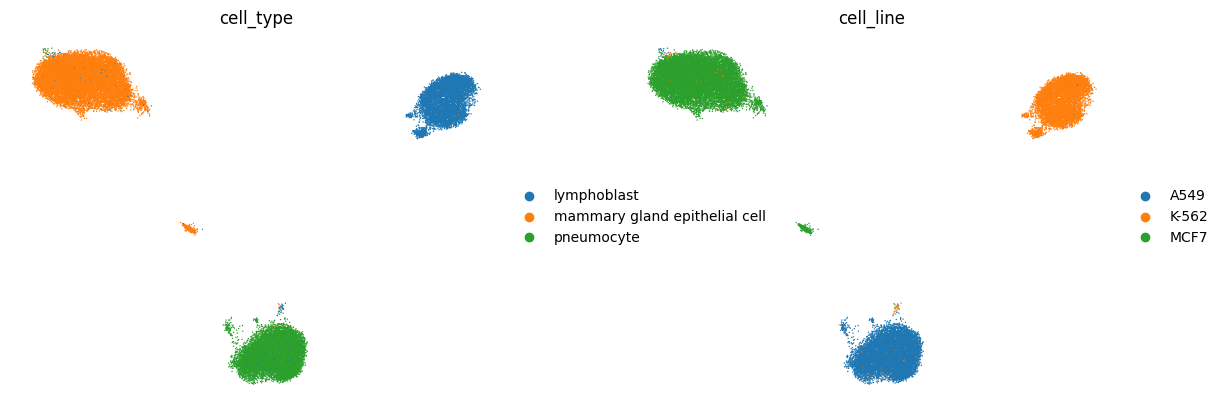

In [6]:
umap_idx = np.random.default_rng(SEED).choice(te, size=min(UMAP_N, len(te)), replace=False)
ad_te = adata[umap_idx].copy()
sc.pp.neighbors(ad_te, use_rep="X_state")
sc.tl.umap(ad_te)
color_keys = [c for c in ["cell_type", "cell_line"] if c in ad_te.obs.columns]
sc.pl.umap(ad_te, color=color_keys, ncols=len(color_keys), frameon=False, show=True)

In [7]:
# ---- metrics (all on mean profiles, scaleflow-style) ----
ctrl_mean = {cl: X[(cell_line == cl) & is_ctrl].mean(0) for cl in np.unique(cell_line)}

def r2_per_cellline(true, pred, labels):
    scores = {cl: float(r2_score(true[labels == cl].mean(0), pred[labels == cl].mean(0)))
              for cl in np.unique(labels)}
    return float(np.mean(list(scores.values()))), scores

def delta_metrics(true, pred, labels, drugs, treated, min_cells=MIN_CELLS_DELTA):
    """Per (cell_line, drug): R2 and Pearson r of the perturbation delta
    (mean_treated - control_mean), true vs reconstructed, across genes."""
    r2s, prs, rows = [], [], []
    for cl in np.unique(labels):
        cl_treated = treated & (labels == cl)
        base = ctrl_mean[cl]
        for dg in np.unique(drugs[cl_treated]):
            m = cl_treated & (drugs == dg)
            if int(m.sum()) < min_cells:
                continue
            td = true[m].mean(0) - base
            rd = pred[m].mean(0) - base
            r2s.append(float(r2_score(td, rd)))
            prs.append(float(np.corrcoef(td, rd)[0, 1]) if td.std() > 0 and rd.std() > 0 else np.nan)
            rows.append((cl, dg, int(m.sum()), r2s[-1], prs[-1]))
    if not r2s:
        return dict(r2_mean=np.nan, r2_med=np.nan, pr_mean=np.nan, pr_med=np.nan, n=0, rows=rows)
    return dict(r2_mean=float(np.mean(r2s)), r2_med=float(np.median(r2s)),
                pr_mean=float(np.nanmean(prs)), pr_med=float(np.nanmedian(prs)),
                n=len(r2s), rows=rows)

def per_gene_pearson(true, pred):
    t = true - true.mean(0); p = pred - pred.mean(0)
    den = np.sqrt((t ** 2).sum(0) * (p ** 2).sum(0))
    with np.errstate(invalid="ignore", divide="ignore"):
        r = (t * p).sum(0) / den
    return r[np.isfinite(r)]

def report(true, pred, labels, drugs, treated, title):
    r2_pb, r2_cl = r2_per_cellline(true, pred, labels)
    d = delta_metrics(true, pred, labels, drugs, treated)
    pg = per_gene_pearson(true, pred)
    print(f"{title}:")
    print(f"  per-cell-line pseudobulk R2 = {r2_pb:.3f}  ("
          + "  ".join(f"{k}={v:.3f}" for k, v in r2_cl.items()) + ")")
    print(f"  perturbation-delta  (n={d['n']} conds >= {MIN_CELLS_DELTA} cells):")
    print(f"      R2      mean={d['r2_mean']:.3f}  median={d['r2_med']:.3f}")
    print(f"      Pearson mean={d['pr_mean']:.3f}  median={d['pr_med']:.3f}")
    print(f"  secondary: median per-gene r = {np.median(pg):.3f}")
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    for cl in np.unique(labels):
        m = labels == cl
        ax[0].scatter(true[m].mean(0), pred[m].mean(0), s=5, alpha=0.5, label=f"{cl} (R2={r2_cl[cl]:.2f})")
    lo = min(true.mean(0).min(), pred.mean(0).min()); hi = max(true.mean(0).max(), pred.mean(0).max())
    ax[0].plot([lo, hi], [lo, hi], "k--", lw=1); ax[0].legend(fontsize=7)
    ax[0].set_xlabel("true mean expr"); ax[0].set_ylabel("recon mean expr"); ax[0].set_title("pseudobulk per cell line")
    ax[1].hist([r[3] for r in d["rows"]], bins=30)
    if np.isfinite(d["r2_med"]):
        ax[1].axvline(d["r2_med"], color="r", ls="--", label=f"median {d['r2_med']:.2f}"); ax[1].legend(fontsize=7)
    ax[1].set_xlabel("per-condition delta R2"); ax[1].set_ylabel("conditions"); ax[1].set_title("delta R2")
    ax[2].hist([r[4] for r in d["rows"]], bins=30)
    if np.isfinite(d["pr_med"]):
        ax[2].axvline(d["pr_med"], color="r", ls="--", label=f"median {d['pr_med']:.2f}"); ax[2].legend(fontsize=7)
    ax[2].set_xlabel("per-condition delta Pearson r"); ax[2].set_ylabel("conditions"); ax[2].set_title("delta Pearson")
    plt.tight_layout(); plt.show()
    return r2_pb, d

In [8]:
# ---- train in chunks, logging held-out test metrics + train loss to wandb ----
def train_log_test(module, in_tr, tgt_tr, in_te, tgt_te, labels_te, drug_te, treated_te,
                   total_iters, chunk, wandb_run=None, **train_kw):
    state, hist, done = None, [], 0
    while done < total_iters:
        n = min(chunk, total_iters - done)
        state, losses = module.train(in_tr, tgt_tr, n_iters=n, state=state, seed=SEED + done, **train_kw)
        done += n
        train_loss = float(np.mean(losses[-1000:]))
        out = module.apply({"params": state.params}, jnp.asarray(in_te), training=False)
        recon = np.asarray(out[0] if isinstance(out, tuple) else out)
        r2pb, _ = r2_per_cellline(tgt_te, recon, labels_te)
        d = delta_metrics(tgt_te, recon, labels_te, drug_te, treated_te)
        hist.append((done, r2pb, d["r2_mean"], d["pr_mean"]))
        print(f"  iter {done:>7d}  loss={train_loss:.4f}  pseudobulk R2={r2pb:.3f}  "
              f"delta R2={d['r2_mean']:.3f}  delta Pearson={d['pr_mean']:.3f}")
        if wandb_run is not None:
            wandb_run.log({
                "train/loss": train_loss,
                "test/pseudobulk_r2": r2pb,
                "test/delta_r2_mean": d["r2_mean"], "test/delta_r2_median": d["r2_med"],
                "test/delta_pearson_mean": d["pr_mean"], "test/delta_pearson_median": d["pr_med"],
            }, step=done)
    return state, hist

def plot_curves(hist, title):
    it_, pb_, dr2_, dpr_ = zip(*hist)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(it_, pb_, marker="o", label="pseudobulk R2")
    ax.plot(it_, dr2_, marker="s", label="delta R2 (mean)")
    ax.plot(it_, dpr_, marker="^", label="delta Pearson (mean)")
    ax.set_xlabel("iteration"); ax.set_ylabel("test metric"); ax.set_title(title)
    ax.legend(); plt.tight_layout(); plt.show()

## Part A — learned-latent autoencoder

In [9]:
ae = Autoencoder(
    gene_dim=X.shape[1], latent_dim=LATENT_DIM,
    encoder_hidden=(512, 256), decoder_hidden=DEC_HIDDEN, dropout_rate=0.1,
)
runA = wandb.init(
    project=WANDB_PROJECT, group=WANDB_GROUP, name=f"AE_dec{DEC_TAG}", job_type="learned_ae", reinit=True,
    config=dict(part="A_learned_ae", input="genes", latent_dim=LATENT_DIM, encoder_hidden=[512, 256],
                decoder_hidden=list(DEC_HIDDEN), dropout=0.1, n_iters=N_ITERS, batch_size=BATCH_SIZE,
                lr=LR, n_top_genes=N_TOP_GENES, n_cells=int(X.shape[0]), loss="mse"),
)
ae_state, ae_hist = train_log_test(
    ae, X[tr], X[tr], X[te], X[te], cl_te, drug_te, treated_te,
    total_iters=N_ITERS, chunk=CHUNK, wandb_run=runA, batch_size=BATCH_SIZE, lr=LR,
)

  iter   10000  loss=0.0661  pseudobulk R2=0.993  delta R2=0.354  delta Pearson=0.687


  iter   20000  loss=0.0637  pseudobulk R2=0.993  delta R2=0.369  delta Pearson=0.703


  iter   30000  loss=0.0630  pseudobulk R2=0.994  delta R2=0.379  delta Pearson=0.704


  iter   40000  loss=0.0626  pseudobulk R2=0.994  delta R2=0.395  delta Pearson=0.708


  iter   50000  loss=0.0620  pseudobulk R2=0.994  delta R2=0.389  delta Pearson=0.711


...

  iter  110000  loss=0.0610  pseudobulk R2=0.995  delta R2=0.430  delta Pearson=0.725


  iter  120000  loss=0.0607  pseudobulk R2=0.994  delta R2=0.409  delta Pearson=0.720


  iter  130000  loss=0.0608  pseudobulk R2=0.995  delta R2=0.432  delta Pearson=0.725


  iter  140000  loss=0.0607  pseudobulk R2=0.994  delta R2=0.403  delta Pearson=0.721


  iter  150000  loss=0.0606  pseudobulk R2=0.994  delta R2=0.413  delta Pearson=0.721


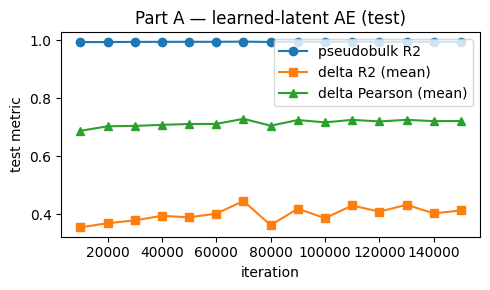

Part A (learned latent):
  per-cell-line pseudobulk R2 = 0.994  (A549=0.995  K-562=0.991  MCF7=0.996)
  perturbation-delta  (n=384 conds >= 20 cells):
      R2      mean=0.413  median=0.544
      Pearson mean=0.721  median=0.767
  secondary: median per-gene r = 0.033


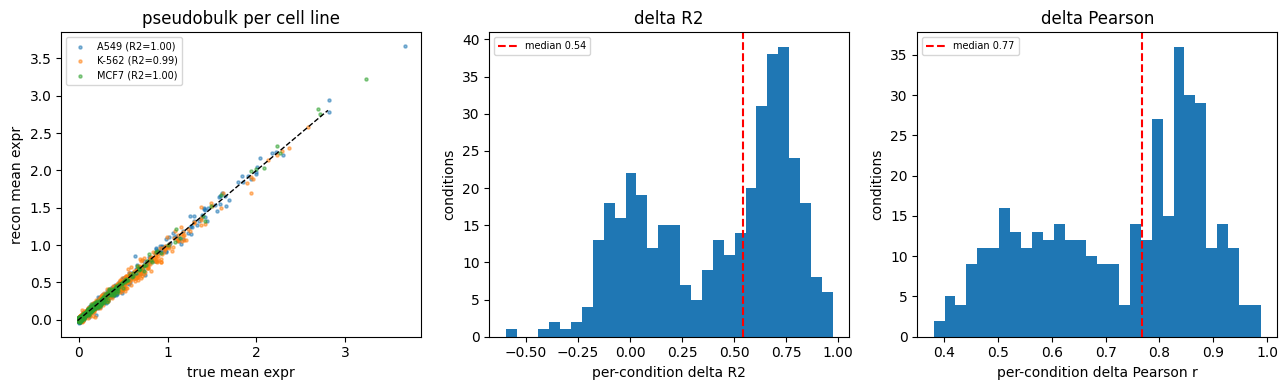

In [10]:
plot_curves(ae_hist, "Part A — learned-latent AE (test)")
ae_recon_te, _ = ae.apply({"params": ae_state.params}, jnp.asarray(X[te]), training=False)
ae_recon_te = np.asarray(ae_recon_te)
r2A_pb, dA = report(X[te], ae_recon_te, cl_te, drug_te, treated_te, "Part A (learned latent)")
runA.summary.update({"final/pseudobulk_r2": r2A_pb, "final/delta_r2_mean": dA["r2_mean"],
                     "final/delta_r2_median": dA["r2_med"], "final/delta_pearson_mean": dA["pr_mean"],
                     "final/delta_pearson_median": dA["pr_med"]})
runA.finish()

## Part B — decode the predefined `X_state` latent

In [11]:
dec = Decoder(output_dim=X.shape[1], hidden_dims=DEC_HIDDEN, dropout_rate=0.1)
runB = wandb.init(
    project=WANDB_PROJECT, group=WANDB_GROUP, name=f"Xstate_dec{DEC_TAG}", job_type="xstate_decoder", reinit=True,
    config=dict(part="B_xstate_decoder", input="X_state", latent_dim=int(X_state.shape[1]),
                decoder_hidden=list(DEC_HIDDEN), dropout=0.1, n_iters=N_ITERS, batch_size=BATCH_SIZE,
                lr=LR, n_top_genes=N_TOP_GENES, n_cells=int(X.shape[0]), loss="mse"),
)
dec_state, dec_hist = train_log_test(
    dec, X_state[tr], X[tr], X_state[te], X[te], cl_te, drug_te, treated_te,
    total_iters=N_ITERS, chunk=CHUNK, wandb_run=runB, batch_size=BATCH_SIZE, lr=LR,
)

  iter   10000  loss=0.0801  pseudobulk R2=0.991  delta R2=0.022  delta Pearson=0.604


  iter   20000  loss=0.0755  pseudobulk R2=0.992  delta R2=0.138  delta Pearson=0.631


  iter   30000  loss=0.0742  pseudobulk R2=0.993  delta R2=0.210  delta Pearson=0.648


  iter   40000  loss=0.0737  pseudobulk R2=0.994  delta R2=0.230  delta Pearson=0.654


  iter   50000  loss=0.0733  pseudobulk R2=0.994  delta R2=0.273  delta Pearson=0.664


...

  iter  110000  loss=0.0721  pseudobulk R2=0.994  delta R2=0.265  delta Pearson=0.671


  iter  120000  loss=0.0718  pseudobulk R2=0.994  delta R2=0.253  delta Pearson=0.665


  iter  130000  loss=0.0718  pseudobulk R2=0.994  delta R2=0.235  delta Pearson=0.655


  iter  140000  loss=0.0717  pseudobulk R2=0.994  delta R2=0.261  delta Pearson=0.664


  iter  150000  loss=0.0715  pseudobulk R2=0.994  delta R2=0.228  delta Pearson=0.657


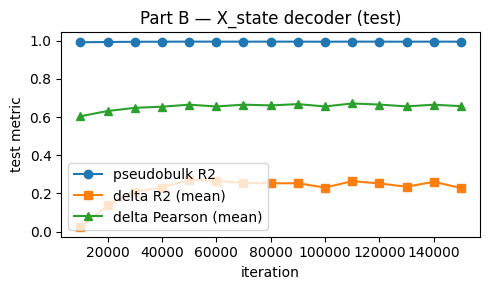

Part B (X_state decoder):
  per-cell-line pseudobulk R2 = 0.994  (A549=0.996  K-562=0.993  MCF7=0.992)
  perturbation-delta  (n=384 conds >= 20 cells):
      R2      mean=0.228  median=0.398
      Pearson mean=0.657  median=0.680
  secondary: median per-gene r = 0.043


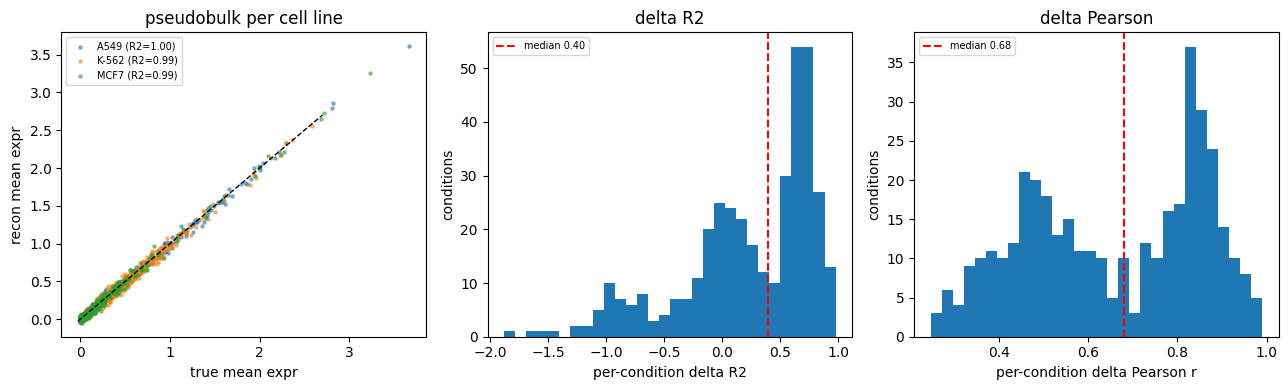

In [12]:
plot_curves(dec_hist, "Part B — X_state decoder (test)")
dec_recon_te = np.asarray(dec.apply({"params": dec_state.params}, jnp.asarray(X_state[te]), training=False))
r2B_pb, dB = report(X[te], dec_recon_te, cl_te, drug_te, treated_te, "Part B (X_state decoder)")
runB.summary.update({"final/pseudobulk_r2": r2B_pb, "final/delta_r2_mean": dB["r2_mean"],
                     "final/delta_r2_median": dB["r2_med"], "final/delta_pearson_mean": dB["pr_mean"],
                     "final/delta_pearson_median": dB["pr_med"]})
runB.finish()

## True vs reconstructed cells on a shared UMAP

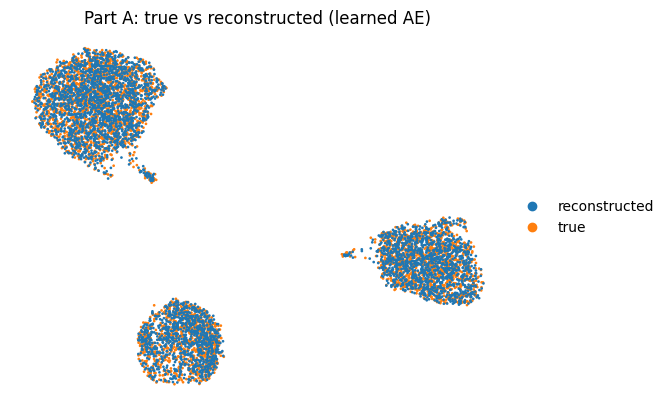

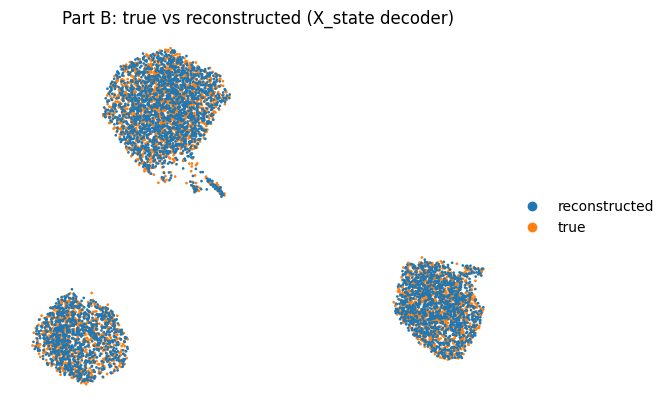

In [13]:
def joint_umap(true, recon, title, n_max=4000, seed=SEED):
    n = min(n_max, true.shape[0])
    sel = np.random.default_rng(seed).choice(true.shape[0], size=n, replace=False)
    Xcat = np.vstack([true[sel], recon[sel]]).astype(np.float32)
    kind = np.array(["true"] * n + ["reconstructed"] * n)
    aj = ad.AnnData(Xcat, obs={"kind": kind})
    sc.pp.pca(aj, n_comps=50); sc.pp.neighbors(aj); sc.tl.umap(aj)
    sc.pl.umap(aj, color="kind", title=title, frameon=False, show=True)

joint_umap(X[te], ae_recon_te, "Part A: true vs reconstructed (learned AE)")
joint_umap(X[te], dec_recon_te, "Part B: true vs reconstructed (X_state decoder)")

## Interpretation

- **Pseudobulk R²** is baseline-dominated (≈1) — uninformative with 3 cell lines.
- **Perturbation-delta R²** measures recovery of the drug effect *with magnitude*;
  **delta Pearson r** measures the effect *direction/shape* independent of scale.
- Compare the wandb runs (`recon_test` group) to see how loss and the delta metrics evolve
  across decoder architectures along training.
- **Next step:** attach the decoder to the flow solver for a gene-expression reconstruction
  loss on top of the cell-state flow-matching loss.

In [14]:
print(f"Part A (learned {LATENT_DIM}):  pseudobulk R2={r2A_pb:.3f}  "
      f"delta R2 mean={dA['r2_mean']:.3f} median={dA['r2_med']:.3f}  "
      f"delta Pearson mean={dA['pr_mean']:.3f} median={dA['pr_med']:.3f}")
print(f"Part B (X_state {X_state.shape[1]}): pseudobulk R2={r2B_pb:.3f}  "
      f"delta R2 mean={dB['r2_mean']:.3f} median={dB['r2_med']:.3f}  "
      f"delta Pearson mean={dB['pr_mean']:.3f} median={dB['pr_med']:.3f}")

Part A (learned 128):  pseudobulk R2=0.994  delta R2 mean=0.413 median=0.544  delta Pearson mean=0.721 median=0.767
Part B (X_state 2058): pseudobulk R2=0.994  delta R2 mean=0.228 median=0.398  delta Pearson mean=0.657 median=0.680
